<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec06_logistic_regression_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 로지스틱 회귀 (Logistic Regression) 실습

이 실습에서는 이진 분류(Binary Classification)를 위한 로지스틱 회귀를 학습합니다:
1. sklearn의 LogisticRegression 사용
2. scipy.optimize를 이용한 직접 구현

**로지스틱 회귀 모델:**
$$\hat{y} = \sigma(W \cdot X) = \frac{1}{1 + e^{-W \cdot X}}$$

**Binary Cross-Entropy 손실:**
$$BCE = -\frac{1}{n}\sum[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]$$

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 (15점)

make_blobs를 사용하여 이진 분류용 데이터셋을 생성합니다.

---

In [1]:
#@title { vertical-output: true}
from scipy import optimize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

### 문제 1-1. 데이터 생성 [5점]

make_blobs를 사용하여 2개의 클러스터 데이터를 생성합니다.

**예상 결과:** 1000개의 샘플, 2개의 특성

In [2]:
#@title { vertical-output: true}
# 데이터 생성
x, y = make_blobs(n_samples=1000, n_features=2, centers=[[1, 1], [2, 2]], cluster_std=0.5)

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"클래스 분포: 0={np.sum(y==0)}, 1={np.sum(y==1)}")

x shape: (1000, 2)
y shape: (1000,)
클래스 분포: 0=500, 1=500


### 문제 1-2. 데이터 시각화 [5점]

두 클래스를 다른 색으로 시각화합니다.

**예상 결과:** 빨간색과 파란색으로 구분된 두 클러스터

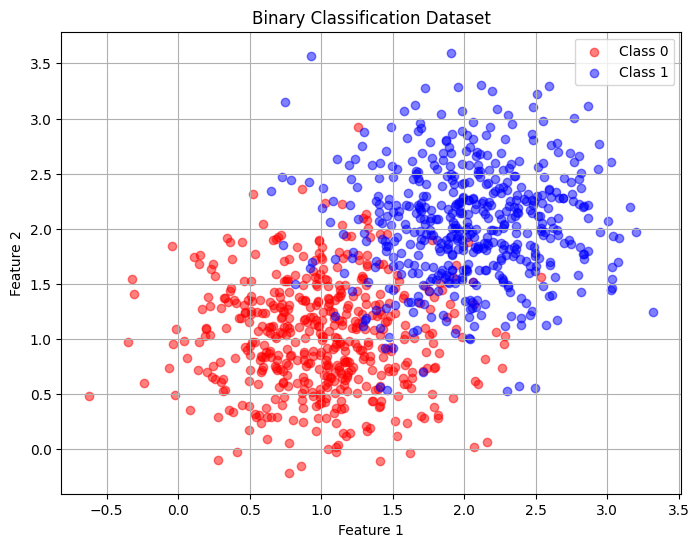

In [3]:
#@title { vertical-output: true}
color = ['red', 'blue']

plt.figure(figsize=(8, 6))
for i in [0, 1]:
    idx = np.where(y == i)
    plt.scatter(x[idx, 0], x[idx, 1], c=color[i], alpha=0.5, label=f'Class {i}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.legend()
plt.grid(True)
plt.show()

### 문제 1-3. 데이터 분할 [5점]

**문제:** train_test_split을 사용하여 데이터를 분할하세요.

**힌트:**
```python
x_train, x_test, y_train, y_test = train_test_split(x, y)
```

**예상 결과:** 훈련 750개, 테스트 250개

In [4]:
#@title { vertical-output: true}
# IMPLEMENT HERE: train_test_split 사용
x_train, x_test, y_train, y_test = train_test_split(x, y)

print(f"훈련 데이터: {x_train.shape[0]}개")
print(f"테스트 데이터: {x_test.shape[0]}개")

훈련 데이터: 750개
테스트 데이터: 250개


---
## Part 2: sklearn LogisticRegression (25점)

sklearn의 LogisticRegression을 사용하여 분류 모델을 학습합니다.

---

### 문제 2-1. 모델 학습 [10점]

**문제:** LogisticRegression 모델을 생성하고 학습시키세요.

**힌트:**
```python
model = LogisticRegression()
model.fit(x_train, y_train)
```

**예상 결과:** 학습 완료된 모델

In [5]:
#@title { vertical-output: true}
# IMPLEMENT HERE: LogisticRegression 생성 및 학습
model = LogisticRegression()
model.fit(x_train, y_train)

print("모델 학습 완료!")
print(f"가중치 (coef): {model.coef_}")
print(f"절편 (intercept): {model.intercept_}")

모델 학습 완료!
가중치 (coef): [[3.76023379 3.04257175]]
절편 (intercept): [-10.2724577]


### 문제 2-2. 예측 및 정확도 계산 [15점]

**문제:** 테스트 데이터로 예측하고 정확도를 계산하세요.

**힌트:**
```python
y_hat = model.predict(x_test)
acc = (y_hat == y_test).mean()
```

**예상 결과:** 정확도 약 90% 이상

In [6]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 예측
y_hat = model.predict(x_test)

# IMPLEMENT HERE: 정확도 계산
acc = (y_hat == y_test).mean()

print(f'Accuracy (sklearn): {acc:.3f}')

Accuracy (sklearn): 0.932


### 결과 시각화

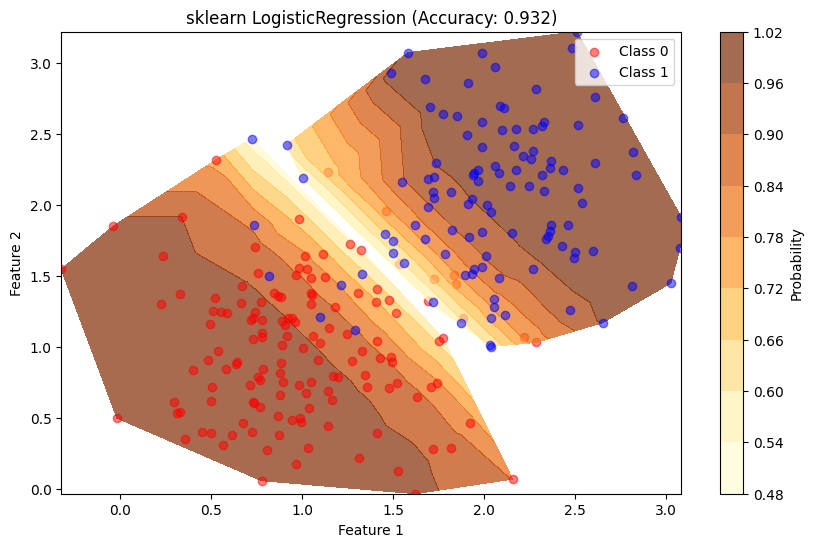

In [7]:
#@title { vertical-output: true}
# 예측 확률
y_hat_prob = model.predict_proba(x_test)

plt.figure(figsize=(10, 6))
for i in [0, 1]:
    idx = np.where(y_hat == i)
    cs = plt.tricontourf(x_test[idx, 0].reshape(-1,),
                         x_test[idx, 1].reshape(-1,),
                         y_hat_prob[idx, i].reshape(-1,),
                         cmap='YlOrBr', alpha=0.7)

    idx = np.where(y_test == i)
    plt.scatter(x_test[idx, 0], x_test[idx, 1], c=color[i], alpha=0.5, label=f'Class {i}')

plt.colorbar(cs, label='Probability')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'sklearn LogisticRegression (Accuracy: {acc:.3f})')
plt.legend()
plt.show()

---
## Part 3: scipy.optimize를 이용한 직접 구현 (60점)

Binary Cross-Entropy 손실 함수를 정의하고 scipy.optimize.minimize로 최적화합니다.

**모델:** $\hat{y} = \sigma(w_1x_1 + w_2x_2 + b)$

---

### 문제 3-1. BCE 손실 함수 구현 [30점]

Binary Cross-Entropy 손실 함수를 구현합니다.

**문제:** bce_loss 함수에서 y_hat과 bce를 계산하세요.

**힌트:**
```python
# Sigmoid
y_hat = 1.0 / (1 + np.exp(-X @ W))

# BCE
bce = -y * np.log(y_hat + 1e-8) - (1.0 - y) * np.log(1.0 - y_hat + 1e-8)
loss = bce.mean()
```

**예상 결과:** 최적화 후 손실이 낮아짐

In [8]:
#@title { vertical-output: true}
def bce_loss(W, args):
    """
    Binary Cross-Entropy 손실 함수

    Parameters:
    - W: 가중치 벡터 [w1, w2, b]
    - args: [X, y]

    Returns:
    - loss: BCE 손실
    """
    X = args[0]
    y = args[1]

    # IMPLEMENT HERE: Sigmoid 함수 적용
    y_hat = 1.0 / (1 + np.exp(-X @ W))

    # IMPLEMENT HERE: BCE 계산
    bce = -y * np.log(y_hat + 1e-8) - (1.0 - y) * np.log(1.0 - y_hat + 1e-8)
    loss = bce.mean()

    return loss

# 테스트
print(f"x_train shape: {x_train.shape}")

x_train shape: (750, 2)


### 문제 3-2. 데이터 변환 및 최적화 [15점]

bias를 위해 데이터에 1 열을 추가하고 optimize.minimize를 실행합니다.

**문제:**
1. x_train에 bias 열(1) 추가
2. optimize.minimize 실행

**힌트:**
```python
x_train_with_b = np.hstack([x_train, np.ones([x_train.shape[0], 1])])
result = optimize.minimize(fun=bce_loss, x0=[0, 0, 0], args=[x_train_with_b, y_train])
```

**예상 결과:** 최적화 성공 (success: True)

In [9]:
#@title { vertical-output: true}
# IMPLEMENT HERE: bias 열 추가
x_train_with_b = np.hstack([x_train, np.ones([x_train.shape[0], 1])])

print(f"원본 x_train shape: {x_train.shape}")
print(f"변환 후 x_train_with_b shape: {x_train_with_b.shape}")

# IMPLEMENT HERE: optimize.minimize 실행
result = optimize.minimize(fun=bce_loss, x0=[0, 0, 0], args=[x_train_with_b, y_train])

print("\n최적화 결과:")
print(result)

W = result.x
print(f"\n최적 가중치: w1={W[0]:.4f}, w2={W[1]:.4f}, b={W[2]:.4f}")

원본 x_train shape: (750, 2)
변환 후 x_train_with_b shape: (750, 3)

최적화 결과:
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.18790651366962088
        x: [ 4.412e+00  3.487e+00 -1.193e+01]
      nit: 24
      jac: [-2.980e-07 -5.085e-07 -3.520e-07]
 hess_inv: [[ 1.190e+02  3.715e+01 -2.361e+02]
            [ 3.715e+01  8.467e+01 -1.820e+02]
            [-2.361e+02 -1.820e+02  6.434e+02]]
     nfev: 100
     njev: 25

최적 가중치: w1=4.4122, w2=3.4869, b=-11.9349


### 문제 3-3. 예측 및 정확도 계산 [15점]

**문제:** 학습된 가중치로 테스트 데이터를 예측하고 정확도를 계산하세요.

**힌트:**
```python
x_test_with_b = np.hstack([x_test, np.ones([x_test.shape[0], 1])])
y_hat = 1.0 / (1 + np.exp(-x_test_with_b @ W))
y_hat_cls = (y_hat > 0.5).astype('int8')
```

**예상 결과:** sklearn과 유사한 정확도

In [10]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 테스트 데이터 변환
x_test_with_b = np.hstack([x_test, np.ones([x_test.shape[0], 1])])

# IMPLEMENT HERE: Sigmoid로 확률 계산
y_hat_prob = 1.0 / (1 + np.exp(-x_test_with_b @ W))

# IMPLEMENT HERE: 0.5 기준으로 클래스 분류
y_hat_cls = (y_hat_prob > 0.5).astype('int8')

# IMPLEMENT HERE: 정확도 계산
acc_custom = (y_hat_cls == y_test).mean()

print(f'Accuracy (scipy.optimize): {acc_custom:.3f}')

Accuracy (scipy.optimize): 0.932


### 결과 시각화

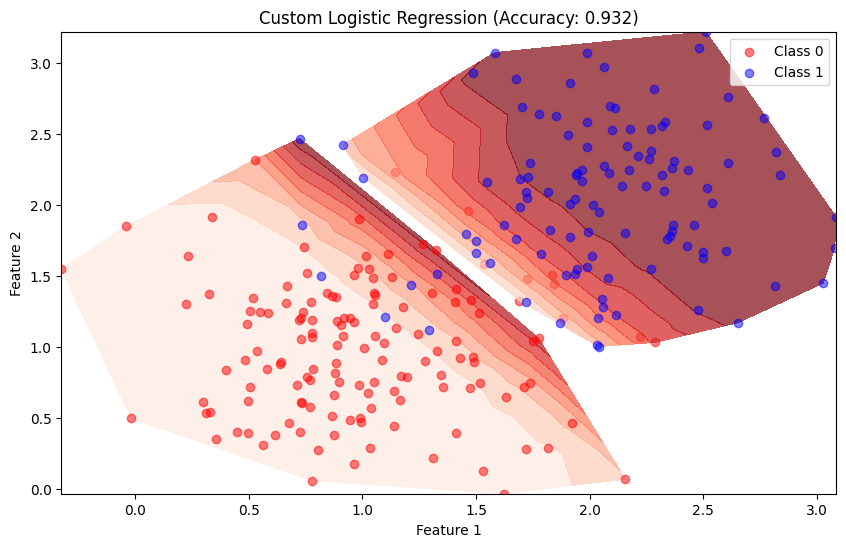

In [11]:
#@title { vertical-output: true}
plt.figure(figsize=(10, 6))

for i in [0, 1]:
    idx = np.where(y_hat_cls == i)
    cs = plt.tricontourf(x_test[idx, 0].reshape(-1,),
                         x_test[idx, 1].reshape(-1,),
                         y_hat_prob[idx].reshape(-1,),
                         cmap='Reds', alpha=0.7)

    idx = np.where(y_test == i)
    plt.scatter(x_test[idx, 0], x_test[idx, 1], c=color[i], alpha=0.5, label=f'Class {i}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Custom Logistic Regression (Accuracy: {acc_custom:.3f})')
plt.legend()
plt.show()

---
## 결과 비교

In [12]:
#@title { vertical-output: true}
print("=" * 50)
print("정확도 비교")
print("=" * 50)
print(f"sklearn LogisticRegression: (Part 2에서 계산)")
print(f"scipy.optimize 직접 구현:  (Part 3에서 계산)")

정확도 비교
sklearn LogisticRegression: (Part 2에서 계산)
scipy.optimize 직접 구현:  (Part 3에서 계산)


---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `logistic_regression_학번_이름.ipynb`, `logistic_regression_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---